In [76]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import weibull_min


In [77]:
def simulate_realistic_viewport_weibull(
    num_steps, 
    damping=0.99, 
    weibull_shape=1.5, 
    weibull_scale=1, 
    start_yaw=0
):
    yaw_trajectory = np.zeros(num_steps)
    pitch_trajectory = np.zeros(num_steps)
    
    current_yaw_drift = 0
    current_pitch_drift = 0
    
    yaw_trajectory[0] = start_yaw
    pitch_trajectory[0] = 0

    for i in range(1, num_steps):
        # Get step sizes from Weibull distribution
        yaw_step_size = weibull_min.rvs(weibull_shape, scale=weibull_scale)
        pitch_step_size = weibull_min.rvs(weibull_shape, scale=weibull_scale)
        
        yaw_step = np.random.choice([-yaw_step_size, yaw_step_size]) * yaw_step_size
        pitch_step = np.random.choice([-pitch_step_size, pitch_step_size]) * pitch_step_size

        current_yaw_drift = (current_yaw_drift * damping) + yaw_step
        current_pitch_drift = (current_pitch_drift * damping) + pitch_step
        
        # Yaw: Add to start and wrap
        yaw_trajectory[i] = (start_yaw + current_yaw_drift) % 360
        
        # Pitch: Clamp
        pitch_trajectory[i] = np.clip(current_pitch_drift, -90, 90)
        
    return yaw_trajectory, pitch_trajectory

if __name__ == '__main__':
    yaw, pitch = simulate_realistic_viewport_weibull(num_steps=2000, damping=0.99, weibull_shape=1.5, weibull_scale=1, start_yaw=180)

In [78]:
def fit_weibull_to_data(data):
    """
    Fit Weibull distribution to real head movement step data.
    Returns (shape, loc, scale) parameters.
    """
    params = weibull_min.fit(data, floc=0)  # floc=0 forces location to 0
    shape, loc, scale = params
    return shape, scale  # loc is usually 0

if __name__ == '__main__':
    # Example usage with dummy data
    real_step_data = np.abs(np.random.randn(1000)) + 0.5  # Replace with real data
    shape, scale = fit_weibull_to_data(real_step_data)
    print(f"Fitted Weibull shape={shape:.3f}, scale={scale:.3f}")

Fitted Weibull shape=2.248, scale=1.472


In [79]:
def get_required_tiles(center_yaw, center_pitch, n=12, fov_yaw=90.0, fov_pitch=90.0):
    """
    Given a center yaw and pitch, compute the required tiles.

    Parameters:
    - center_yaw: Center yaw angle in degrees (0-360).
    - center_pitch: Center pitch angle in degrees (-90 to +90).
    - n: Number of tiles per axis (e.g., 8x8 grid).
    - fov_yaw: Field of view in yaw direction in degrees.
    - fov_pitch: Field of view in pitch direction in degrees.

    Returns:
    - A list of (tile_x, tile_y) tuples representing required tiles.
    """
    tile_size_yaw = 360 / n
    tile_size_pitch = 180 / n  # Pitch ranges from -90 to +90

    # Calculate the FOV boundaries
    half_fov_yaw = fov_yaw / 2
    half_fov_pitch = fov_pitch / 2

    # Determine the min and max yaw and pitch
    min_yaw = (center_yaw - half_fov_yaw) % 360
    max_yaw = (center_yaw + half_fov_yaw) % 360
    min_pitch = max(center_pitch - half_fov_pitch, -90)
    max_pitch = min(center_pitch + half_fov_pitch, 90)

    required_tiles = set()

    # Calculate tile indices for yaw
    if min_yaw < max_yaw:
        yaw_indices = range(int(min_yaw // tile_size_yaw), int(max_yaw // tile_size_yaw) + 1)
    else:
        yaw_indices = list(range(int(min_yaw // tile_size_yaw), n)) + list(range(0, int(max_yaw // tile_size_yaw) + 1))

    # Calculate tile indices for pitch
    pitch_indices = range(int((min_pitch + 90) // tile_size_pitch), int((max_pitch + 90) // tile_size_pitch) + 1)

    # Combine yaw and pitch indices to get required tiles
    for yaw_index in yaw_indices:
        for pitch_index in pitch_indices:
            required_tiles.add((yaw_index % n, pitch_index))

    return list(required_tiles)

In [80]:
def simulate_viewport_with_tiles_weibull(
    num_steps,
    n=8,
    fov_yaw=90.0,
    fov_pitch=90.0,
    damping=0.99,
    yaw_weibull_shape=1.5,
    yaw_weibull_scale=1,
    pitch_weibull_shape=1.5,
    pitch_weibull_scale=1,
    start_yaw=180,
    start_pitch=0
):
    yaw_trajectory = np.zeros(num_steps)
    pitch_trajectory = np.zeros(num_steps)
    
    # Mean-reverting drift values
    current_yaw_drift = 0
    current_pitch_drift = 0
    
    # Set starting position
    yaw_trajectory[0] = start_yaw
    pitch_trajectory[0] = start_pitch
    
    # Store required tiles for each frame
    tiles_per_frame = []
    
    # Get initial tiles
    initial_tiles = get_required_tiles(start_yaw, start_pitch, n, fov_yaw, fov_pitch)
    tiles_per_frame.append(set(initial_tiles))
    
    # Simulate trajectory
    for i in range(1, num_steps):
        # Generate Weibull-distributed step sizes with separate parameters
        yaw_step_size = weibull_min.rvs(
            yaw_weibull_shape, 
            scale=yaw_weibull_scale, 
            size=1
        )[0]
        pitch_step_size = weibull_min.rvs(
            pitch_weibull_shape, 
            scale=pitch_weibull_scale, 
            size=1
        )[0]
        
        print(f"Step {i}: Yaw step size={yaw_step_size:.3f}, Pitch step size={pitch_step_size:.3f}")
        # Randomly choose direction (+ or -)
        yaw_step = np.random.choice([-1, 1]) * yaw_step_size
        pitch_step = np.random.choice([-1, 1]) * pitch_step_size
        
        # Apply mean-reverting logic
        current_yaw_drift = (current_yaw_drift * damping) + yaw_step
        current_pitch_drift = (current_pitch_drift * damping) + pitch_step
        
        # Update positions with wrapping and clamping
        yaw_trajectory[i] = (start_yaw + current_yaw_drift) % 360
        pitch_trajectory[i] = np.clip(current_pitch_drift, -90, 90)
        
        # Get required tiles for this viewport position
        required_tiles = get_required_tiles(
            yaw_trajectory[i], 
            pitch_trajectory[i], 
            n, 
            fov_yaw, 
            fov_pitch
        )
        tiles_per_frame.append(set(required_tiles))

    # Convert to 2D array format (for easier processing)
    max_tiles = max(len(tiles) for tiles in tiles_per_frame)
    
    # Create 2D array: rows=frames, cols=tile indices
    # Use -1 to indicate unused slots
    tiles_array = np.full((num_steps, max_tiles), -1, dtype=int)
    
    for frame_idx, tiles_set in enumerate(tiles_per_frame):
        tiles_list = sorted(list(tiles_set))
        for tile_idx, tile in enumerate(tiles_list):
            # Store as linear index: tile_y * n + tile_x
            tiles_array[frame_idx, tile_idx] = tile[1] * n + tile[0]
    
    return yaw_trajectory, pitch_trajectory, tiles_per_frame, tiles_array



In [81]:
def load_and_concat_files(folder_path):

    all_yaw = []
    all_pitch = []
    files = sorted([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
    
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        try:
            data = np.loadtxt(file_path, delimiter=',')
            if data.ndim == 1:
                all_yaw.append(data[1])
                all_pitch.append(data[2])
            else:
                all_yaw.append(data[:, 1])
                all_pitch.append(data[:, 2])
        except Exception as e:
            print(f"Error loading {filename}: {e}")

    # Concatenate all data
    if all_yaw:
        yaw_concatenated = np.concatenate(all_yaw)
        pitch_concatenated = np.concatenate(all_pitch)

        return yaw_concatenated, pitch_concatenated
    else:
        return np.array([]), np.array([])


if __name__ == '__main__':
    
    yaw_data, pitch_data = load_and_concat_files(
        r'c:\Users\es25591\Workspace\CacheVideoPredict360\Dataset\1\Clan'
    )
    
    if len(yaw_data) > 0:
        print(f"\nYaw range: [{yaw_data.min():.2f}, {yaw_data.max():.2f}]")
        print(f"Pitch range: [{pitch_data.min():.2f}, {pitch_data.max():.2f}]")
        
        # Calculate step sizes for Weibull fitting
        yaw_steps = np.abs(np.diff(yaw_data))
        pitch_steps = np.abs(np.diff(pitch_data))
        
        # Filter out zero steps
        yaw_steps = yaw_steps[yaw_steps > 0]
        pitch_steps = pitch_steps[pitch_steps > 0]
        
        # Fit Weibull to step sizes
        shape_yaw, scale_yaw = fit_weibull_to_data(yaw_steps)
        shape_pitch, scale_pitch = fit_weibull_to_data(pitch_steps)
        
        print(f"\nYaw Weibull: shape={shape_yaw:.3f}, scale={scale_yaw:.3f}")
        print(f"Pitch Weibull: shape={shape_pitch:.3f}, scale={scale_pitch:.3f}")

        # Simulate with fitted Weibull parameters
    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles_weibull(
        num_steps=2000,
        n=8,
        fov_yaw=90.0,
        fov_pitch=90.0,
        damping=0.99,
        yaw_weibull_shape=shape_yaw,
        yaw_weibull_scale=scale_yaw,
        pitch_weibull_shape=shape_pitch,
        pitch_weibull_scale=scale_pitch,
        start_yaw=180
    )


Yaw range: [0.00, 6.28]
Pitch range: [-1.57, 1.57]

Yaw Weibull: shape=0.683, scale=0.020
Pitch Weibull: shape=1.014, scale=0.011
Step 1: Yaw step size=0.010, Pitch step size=0.005
Step 2: Yaw step size=0.005, Pitch step size=0.083
Step 3: Yaw step size=0.054, Pitch step size=0.018
Step 4: Yaw step size=0.016, Pitch step size=0.025
Step 5: Yaw step size=0.188, Pitch step size=0.000
Step 6: Yaw step size=0.016, Pitch step size=0.013
Step 7: Yaw step size=0.013, Pitch step size=0.013
Step 8: Yaw step size=0.047, Pitch step size=0.016
Step 9: Yaw step size=0.006, Pitch step size=0.001
Step 10: Yaw step size=0.012, Pitch step size=0.011
Step 11: Yaw step size=0.021, Pitch step size=0.001
Step 12: Yaw step size=0.000, Pitch step size=0.004
Step 13: Yaw step size=0.025, Pitch step size=0.000
Step 14: Yaw step size=0.095, Pitch step size=0.002
Step 15: Yaw step size=0.024, Pitch step size=0.005
Step 16: Yaw step size=0.014, Pitch step size=0.008
Step 17: Yaw step size=0.014, Pitch step size=

C:\Users\es25591\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_continuous_distns.py:2750: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


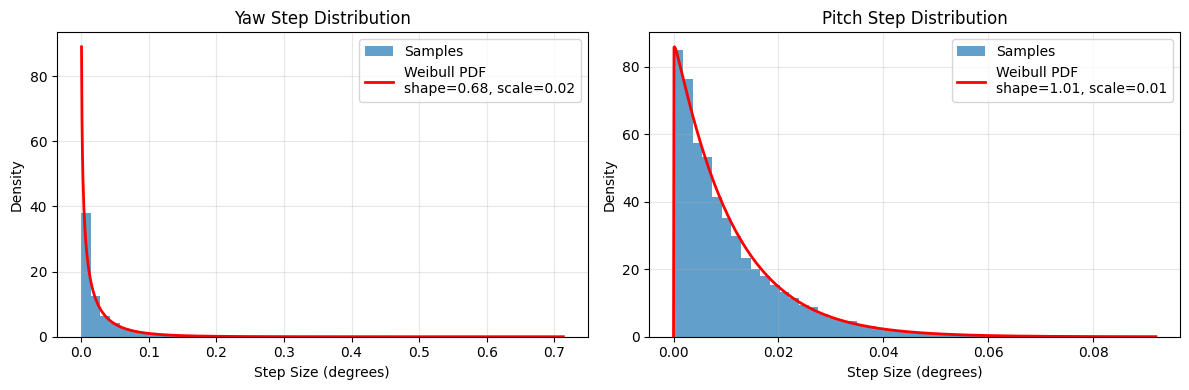

Yaw steps - Mean: 0.026, Std: 0.038
Pitch steps - Mean: 0.011, Std: 0.011


In [82]:
import matplotlib.pyplot as plt

def plot_weibull_step_distributions(yaw_shape, yaw_scale, pitch_shape, pitch_scale, n_samples=10000):
    """Plot Weibull distributions for yaw and pitch steps"""
    # Generate samples
    yaw_samples = weibull_min.rvs(yaw_shape, scale=yaw_scale, size=n_samples)
    pitch_samples = weibull_min.rvs(pitch_shape, scale=pitch_scale, size=n_samples)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot yaw distribution
    axes[0].hist(yaw_samples, bins=50, density=True, alpha=0.7, label='Samples')
    x = np.linspace(0, yaw_samples.max(), 1000)
    pdf = weibull_min.pdf(x, yaw_shape, scale=yaw_scale)
    axes[0].plot(x, pdf, 'r-', lw=2, label=f'Weibull PDF\nshape={yaw_shape:.2f}, scale={yaw_scale:.2f}')
    axes[0].set_xlabel('Step Size (degrees)')
    axes[0].set_ylabel('Density')
    axes[0].set_title('Yaw Step Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot pitch distribution
    axes[1].hist(pitch_samples, bins=50, density=True, alpha=0.7, label='Samples')
    x = np.linspace(0, pitch_samples.max(), 1000)
    pdf = weibull_min.pdf(x, pitch_shape, scale=pitch_scale)
    axes[1].plot(x, pdf, 'r-', lw=2, label=f'Weibull PDF\nshape={pitch_shape:.2f}, scale={pitch_scale:.2f}')
    axes[1].set_xlabel('Step Size (degrees)')
    axes[1].set_ylabel('Density')
    axes[1].set_title('Pitch Step Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"Yaw steps - Mean: {yaw_samples.mean():.3f}, Std: {yaw_samples.std():.3f}")
    print(f"Pitch steps - Mean: {pitch_samples.mean():.3f}, Std: {pitch_samples.std():.3f}")

if __name__ == '__main__':
    plot_weibull_step_distributions(
        yaw_shape=shape_yaw,
        yaw_scale=scale_yaw,
        pitch_shape=shape_pitch,
        pitch_scale=scale_pitch,
        n_samples=10000
    )

Step 1: Yaw step size=3.434, Pitch step size=0.320
Step 2: Yaw step size=1.013, Pitch step size=1.317
Step 3: Yaw step size=2.232, Pitch step size=0.163
Step 4: Yaw step size=3.327, Pitch step size=0.894
Step 5: Yaw step size=1.289, Pitch step size=0.522
Step 6: Yaw step size=1.083, Pitch step size=0.168
Step 7: Yaw step size=1.215, Pitch step size=1.623
Step 8: Yaw step size=3.030, Pitch step size=0.113
Step 9: Yaw step size=1.279, Pitch step size=1.440
Step 10: Yaw step size=0.648, Pitch step size=0.541
Step 11: Yaw step size=0.861, Pitch step size=1.193
Step 12: Yaw step size=0.973, Pitch step size=0.212
Step 13: Yaw step size=2.495, Pitch step size=0.587
Step 14: Yaw step size=0.253, Pitch step size=0.346
Step 15: Yaw step size=1.903, Pitch step size=0.762
Step 16: Yaw step size=2.599, Pitch step size=1.245
Step 17: Yaw step size=1.148, Pitch step size=0.903
Step 18: Yaw step size=1.208, Pitch step size=0.834
Step 19: Yaw step size=1.216, Pitch step size=0.516
Step 20: Yaw step siz

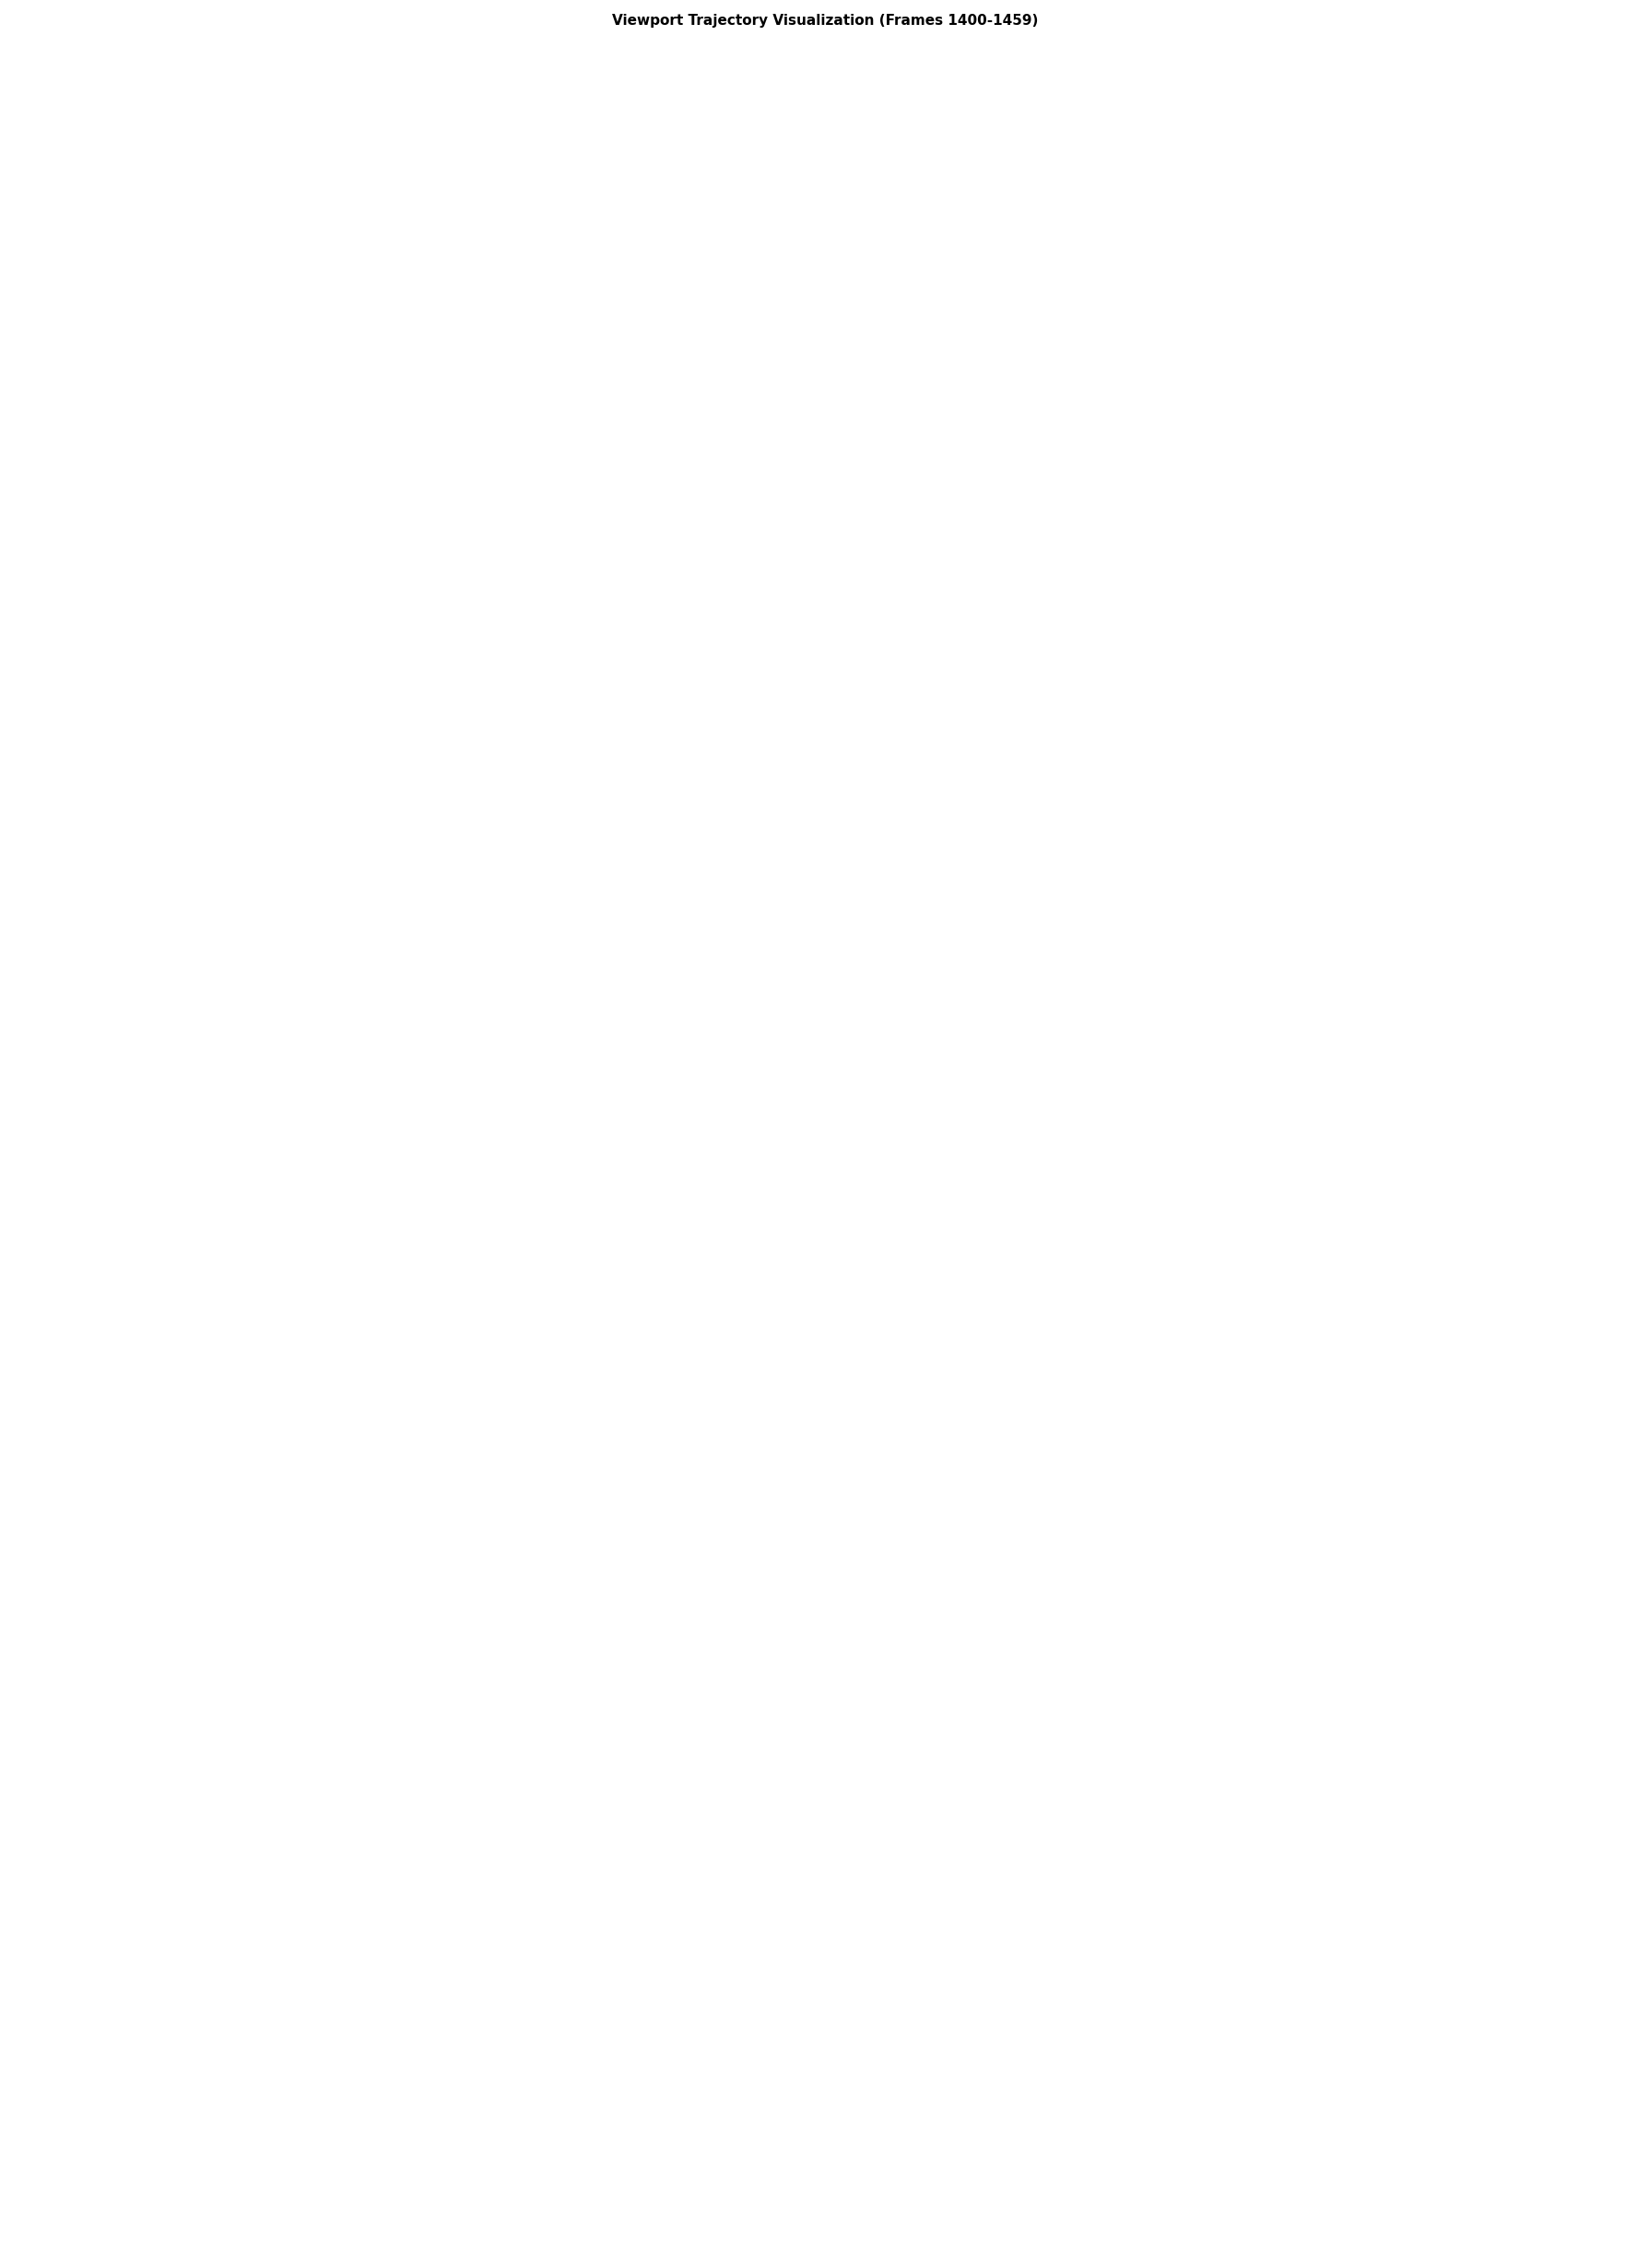

In [83]:
def visualize_trajectory_sequence(
    yaw, 
    pitch, 
    tiles_per_frame, 
    n=8, 
    fov_yaw=90, 
    fov_pitch=90,
    start_frame=0, 
    num_frames_to_show=6, 
    cols=3
):
    """
    Visualizes a sequence of frames from the trajectory showing viewport and required tiles.
    
    Parameters:
    - yaw: Array of yaw positions
    - pitch: Array of pitch positions
    - tiles_per_frame: List of sets containing required tiles
    - n: Grid size (8x8)
    - fov_yaw, fov_pitch: Field of view
    - start_frame: Which frame to start visualization from
    - num_frames_to_show: How many frames to display
    - cols: Number of columns in subplot grid
    """
    rows = int(np.ceil(num_frames_to_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = axes.flatten() if num_frames_to_show > 1 else [axes]
    
    for idx in range(num_frames_to_show):
        frame_num = start_frame + idx
        if frame_num >= len(yaw):
            axes[idx].axis('off')
            continue
            
        ax = axes[idx]
        
        # Get viewport parameters for this frame
        center_yaw = yaw[frame_num]
        center_pitch = pitch[frame_num]
        required_tiles = tiles_per_frame[frame_num]
        
        # Create tile grid
        tile_grid = np.zeros((n, n))
        
        # Mark required tiles
        for tile_x, tile_y in required_tiles:
            if 0 <= tile_x < n and 0 <= tile_y < n:
                tile_grid[tile_y, tile_x] = 1
        
        # Display the grid
        ax.imshow(
            tile_grid,  
            interpolation='nearest', 
            origin='lower',
            cmap='RdYlGn',
            extent=[0, 360, -90, 90], 
            aspect='auto', 
            vmin=0, 
            vmax=1
        )
        
        # Draw grid lines
        tile_size_yaw = 360 / n
        tile_size_pitch = 180 / n
        
        for i in range(n + 1):
            ax.axvline(
                i * tile_size_yaw, color='gray', linewidth=0.3, alpha=0.5
            )
            ax.axhline(
                -90 + i * tile_size_pitch, color='gray', linewidth=0.3, alpha=0.5
           )
        
        # Draw viewport FOV rectangle
        half_fov_yaw = fov_yaw / 2
        half_fov_pitch = fov_pitch / 2
        
        min_yaw = center_yaw - half_fov_yaw
        max_yaw = center_yaw + half_fov_yaw
        min_pitch = max(center_pitch - half_fov_pitch, -90)
        max_pitch = min(center_pitch + half_fov_pitch, 90)
        
        # Handle yaw wrapping
        if min_yaw < 0 or max_yaw > 360:
            if min_yaw < 0:
                ax.add_patch(plt.Rectangle(
                    (min_yaw + 360, min_pitch), 
                    -min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (0, min_pitch), 
                    max_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
            else:
                ax.add_patch(plt.Rectangle(
                    (min_yaw, min_pitch), 
                    360 - min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (0, min_pitch), 
                    max_yaw - 360, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
        else:
            ax.add_patch(plt.Rectangle(
                (min_yaw, min_pitch), 
                fov_yaw, 
                max_pitch - min_pitch,
                fill=False, 
                edgecolor='blue', 
                linewidth=1.5
            ))
        
        # Mark center
        ax.plot(center_yaw, center_pitch, 'r*', markersize=8)
        
        # Set labels and limits
        ax.set_xlim(0, 360)
        ax.set_ylim(-90, 90)
        ax.set_title(f'Frame {frame_num}\n({center_yaw:.1f}°, {center_pitch:.1f}°)\n{len(required_tiles)} tiles',
                     fontsize=9)
        ax.set_xlabel('Yaw', fontsize=8)
        ax.set_ylabel('Pitch', fontsize=8)
        ax.tick_params(labelsize=7)
    
    # Hide any unused subplots
    for idx in range(num_frames_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Viewport Trajectory Visualization (Frames {start_frame}-{start_frame+num_frames_to_show-1})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    num_frames = 1000
    n_tiles = 4

    # Example 1: More exploratory in yaw (larger scale), less in pitch
    yaw, pitch, tiles, tile_array = simulate_viewport_with_tiles_weibull(
        num_steps=1000,
        n=4,
        fov_yaw=90.0,
        fov_pitch=90.0,
        damping=0.99,
        yaw_weibull_shape=1.8,      # More peaked distribution
        yaw_weibull_scale=2.0,      # Larger steps in yaw
        pitch_weibull_shape=1.2,    # More exponential-like
        pitch_weibull_scale=0.8,    # Smaller steps in pitch
        start_yaw=180,
        start_pitch=0
    )


    for i in range(num_frames):
        print(f"Frame {i}: Yaw={yaw[i]:.2f}, Pitch={pitch[i]:.2f}, Tiles={tiles_per_frame[i]}")

    print("Visualizing trajectory sequence...\n")

    visualize_trajectory_sequence(
        yaw, 
        pitch, 
        tiles_per_frame, 
        n=n_tiles, 
        fov_yaw=90, 
        fov_pitch=50,
        start_frame=1400, 
        num_frames_to_show=60, 
        cols=6
    )